**Retail Sales Data Analysis Using Python**

In [ ]:
# Retail Sales Data Analysis Using Python

# Project Overview
# This project analyzes retail sales data using Python to uncover business insights related to sales trends, customer behavior, product performance, and regional performance.

# Tools Used
# - Python
# - Pandas
# - NumPy
# - Matplotlib

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load Dataset**

In [ ]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

**_Customers Table_**\
_Data Understanding_

In [ ]:
# Customers Table Check
customers.head()
customers.tail()
customers.info()
customers.shape
customers.columns
customers.describe()
customers.isnull().sum()
customers.duplicated().sum()

In [ ]:
# Check Datatype
print(customers['SignupDate'].dtype)
# Change Datatype
customers['SignupDate'] = pd.to_datetime(customers['SignupDate'])

In [ ]:
# Change Customers Colums Name Into Snake Case
customers.rename(columns={'CustomerID':"customer_id","CustomerName":"customer_name",
                          "Segment":"segment","State":"state","City":"city","SignupDate":"signup_date"},inplace=True)

**_Product Table_**\
_Data Understanding_

In [ ]:
# Products Table Check
products.head()
products.tail()
products.info()
products.columns
products.describe()
products.shape
products.isnull().sum()
products.duplicated().sum()

In [ ]:
# Change Products Colums Name Into Snake Case
products.rename(columns={'ProductID' : 'product_id','Category' : 'category', 'SubCategory' : 'sub_category',
                         'ProductName' : 'product_name','CostPrice' : 'cost_price','SellingPrice':'selling_price'},inplace=True)

**_Orders Table_**\
_Data Understanding_

In [ ]:
# Orders Table Check
orders.head()
orders.tail()
orders.shape
orders.columns
orders.info()
orders.describe()
orders.isnull().sum()

In [ ]:
# Check Datatype
print(orders[['OrderDate','ShipDate']].dtypes)
# Change Datatype
orders['OrderDate'] = pd.to_datetime(orders['OrderDate'])
orders['ShipDate'] = pd.to_datetime(orders['ShipDate'])

In [ ]:
# Extract Month & Year
orders['Year'] = orders['OrderDate'].dt.year
orders['Month_Name'] = orders['OrderDate'].dt.month_name()
orders['Year_Month'] = orders['OrderDate'].dt.to_period('M')

In [ ]:
# Change Orders Colums Name Into Snake Case
orders.rename(columns={'OrderID':'order_id','CustomerID' :'customer_id','ProductID':'product_id','OrderDate':'order_date',
                        'ShipDate':'ship_date','ShipMode':'ship_mode','PaymentMode':'payment_mode',	'Quantity':'quantity',
                        'Discount':'discount','Sales':'sales','Profit':'profit','Year':'year','Month_Name':'month_name','Year_Month':'year_month'},inplace=True)

*Exploratory Data Analysis*

* Matrix

In [ ]:
# Matrix
Matrix = pd.DataFrame({
                       "Total Sales":[round(orders['sales'].sum())],
                       "Total Profit":round(orders['profit'].sum()),
                       "Profit Margin":str(round((orders['profit'].sum()/orders['sales'].sum())*100))+"%",
                       "Total Products":orders['product_id'].nunique(),
                       "Total Customers":orders['customer_id'].nunique(),
                       "Total Orders":orders['order_id'].count(),
                       "Total Quantity":orders['quantity'].sum(),
                       })
# Matrix
Matrix

* Joining Customer & Orders Table

In [ ]:
# Joining Customers & orders Table
customer_orders = pd.merge(orders,customers,on='customer_id',how='left')

In [ ]:
# Creating Customer Matrix
customer_matrix = customer_orders.groupby('customer_name').agg(total_sales=('sales','sum'),
                                                               total_average=('sales','mean'),
                                                               total_orders = ('order_id','count'),
                                                               total_quantity=('quantity','sum'),
                                                               first_order= ('order_date','min'),
                                                               last_order=('order_date','max'))
customer_matrix['customer_years'] = (customer_matrix["last_order"]-customer_matrix["first_order"]).dt.days/365
customer_matrix=customer_matrix.round(1).sort_values(by=['total_sales'],ascending=False)

In [ ]:
# Customer Matrix
customer_matrix

In [ ]:
# top 5 customer by sales
top5_custmomer = customer_orders.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(5)
# bottom 5 customer by sales
bottom5_custmomer = customer_orders.groupby('customer_name')['sales'].sum().sort_values(ascending=False).tail(5)
# top & bottom customer by sales
print(top5_custmomer)
print(bottom5_custmomer)

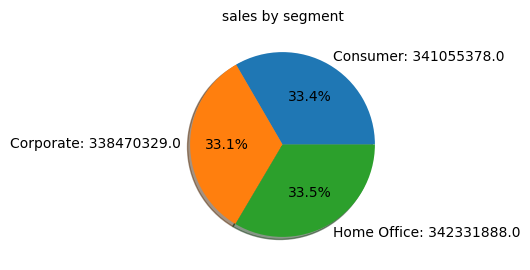

In [32]:
# Sales By Segment
segment = customer_orders.groupby('segment')['sales'].sum().round(0)
# Labels
sales_labels = [f'{key}: {round(value,0)}'for key, value in zip(segment.index,segment.values)]
# Pie Chart
segment.plot(kind='pie',labels=sales_labels,autopct='%1.1f%%',figsize=(3,3),shadow=True)
# Title
plt.title("sales by segment",size=10)
plt.show()

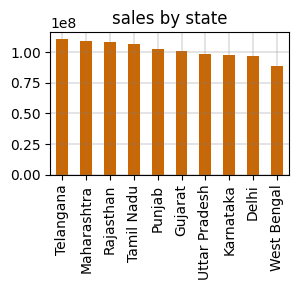

state
Telangana        110821672.0
Maharashtra      109192059.0
Rajasthan        108659317.0
Tamil Nadu       106985112.0
Punjab           102810463.0
Gujarat          100759007.0
Uttar Pradesh     99030576.0
Karnataka         97475103.0
Delhi             96936277.0
West Bengal       89188010.0
Name: sales, dtype: float64


In [33]:
# sales by state
state_sales = customer_orders.groupby('state')['sales'].sum().sort_values(ascending=False).round(0)
state_sales.plot(kind='bar',figsize=(3,3),color='#ca6702')
plt.title('sales by state')
plt.xlabel(None)
plt.grid(True,color='grey',linewidth=0.3)
plt.tight_layout()
plt.show()
print(state_sales)

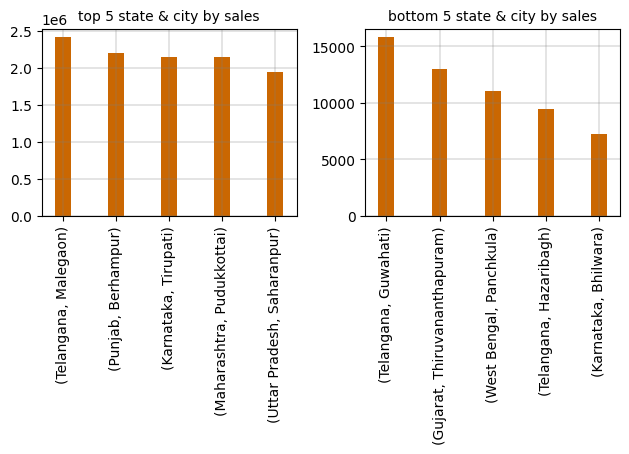

In [34]:
state_city_sales = customer_orders.groupby(['state','city'])['sales'].sum().sort_values(ascending=False)
# Top 5 Sales By State & City
top_state_city = state_city_sales.head(5)
bottom_state_city = state_city_sales.tail(5)
plt.subplot(1,2,1)
top_state_city.plot(kind='bar',width=0.3,color='#ca6702')
plt.title('top 5 state & city by sales',size=10)
plt.xlabel(None)
plt.grid(True,color='grey',linewidth=0.3)
# Bottom 5 Sales By State & City
plt.subplot(1,2,2)
bottom_state_city.plot(kind='bar',width=0.3,color='#ca6702')
plt.title('bottom 5 state & city by sales',size=10)
plt.xlabel(None)
plt.grid(True,color='grey',linewidth=0.3)
plt.tight_layout()
plt.show()

* Product Analysis

In [ ]:
# Joining Orders With Product
products_orders = pd.merge(orders,products,on='product_id',how='left')
# Product Cost
products_orders['total_cost']= products_orders['cost_price']*products_orders['quantity']
# Product Matrix
product_matrix = products_orders.groupby('product_name').agg(total_sales=('sales','sum'),
                                                             product_cost=('total_cost','sum'),
                                                             total_order=('order_id','count'),
                                                             total_quantity=('quantity','sum'))
# Profit Margin
product_matrix.insert(2,'profit_margin',(product_matrix['total_sales']-product_matrix['product_cost'])*100/product_matrix['total_sales'])
# Product_Matrix
product_matrix= product_matrix.sort_values(by='total_sales',ascending=False).round(0)
product_matrix

Top & Bottom 5 Product

In [ ]:
# Top & Bottom 5 Products By Sales 
top5_products = products_orders.groupby('product_name')['sales'].sum().sort_values(ascending=False).round(0).nlargest(5)
bottom5_products = products_orders.groupby('product_name')['sales'].sum().sort_values(ascending=False).round(0).nsmallest(5)

In [ ]:
# Top 5 Product
print(top5_products)
# Bottom Product
print(bottom5_products)

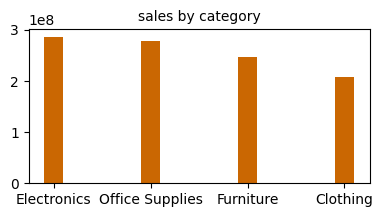

In [36]:
# Sales By Category 
category_sales = products_orders.groupby('category')['sales'].sum().sort_values(ascending=False).round(0)
fig,ax= plt.subplots(figsize=(4.4,2))
ax.bar(category_sales.index,category_sales.values,width=0.2,color='#ca6702')
ax.set_title('sales by category',size=10)
plt.show()

In [ ]:
# Sales By Subcategory
subcategory_sales = products_orders.groupby('sub_category')['sales'].sum().sort_values(ascending=False).round(0)
print(subcategory_sales)

*KPI & Trend Analysis*

* Month Over Month Growth

In [ ]:
monthly_sales = orders.groupby('year_month')['sales'].sum()
mom_growth = (monthly_sales.pct_change()*100).round(2)
print(mom_growth)


* Year Over Year Growth

In [ ]:
year_sales = orders.groupby('year')['sales'].sum()
yoy_growth = (year_sales.pct_change()*100).round(2)
yoy_growth

* Running Total

In [ ]:
# Year Wise Running Total
yearly_sales = orders.groupby('year')['sales'].sum()
summary = pd.DataFrame({'sales':yearly_sales,'running_total':yearly_sales.cumsum()})
print(round(summary,0).astype(int))


In [ ]:
# Month Wise Running Total
monthly_sales = orders.groupby('year_month')['sales'].sum()
summary2= pd.DataFrame({'sales':monthly_sales,'running_total':monthly_sales.cumsum()})
print(round(summary2,0).astype(int))


* Rolling 3 Month Average

In [ ]:
summary3=pd.DataFrame({'sales':monthly_sales,'rolling_3month':monthly_sales.rolling(window=3).mean()})
print(summary3.round(0).astype('Int64'))